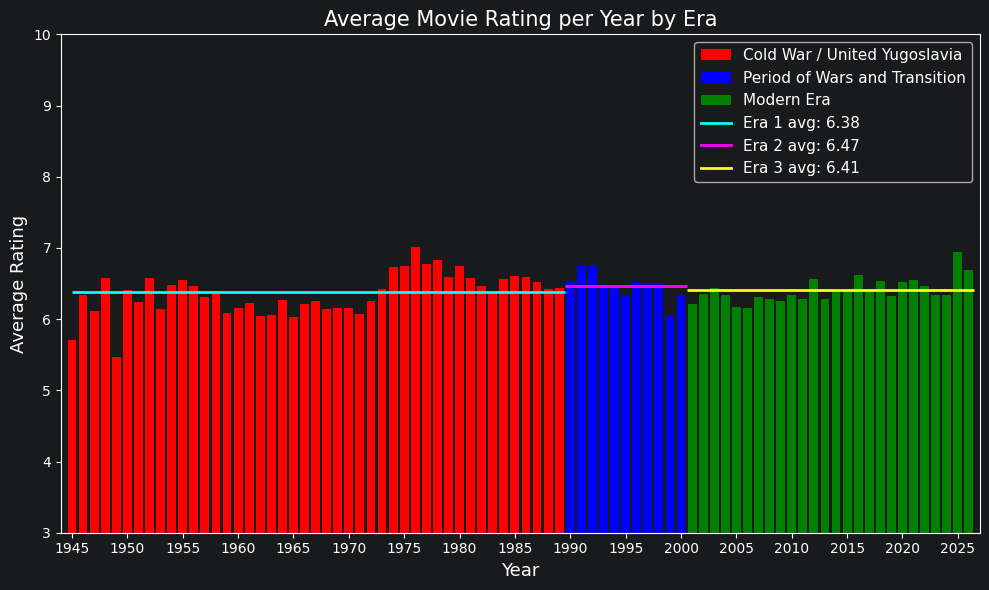

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data/balkan_movies_confirmed.csv')

#use imdb_rating as primary, fall back to tmdb_rating if missing
df['rating'] = df['imdb_rating'].combine_first(df['tmdb_rating'])
df = df.dropna(subset=['year_final', 'rating'])
df = df[df['rating'] >= 0.5]
df['year'] = df['year_final'].astype(int)

#average rating per year
avg_per_year = df.groupby('year')['rating'].mean()

#year range starting from 1945
all_years = np.arange(1945, avg_per_year.index.max() + 1)
avg_per_year = avg_per_year.reindex(all_years)  # missing years become NaN

def era_color(year):
    if year <= 1989:
        return 'red'
    elif year <= 2000:
        return 'blue'
    else:
        return 'green'

colors = [era_color(y) for y in all_years]

#averages
era1_avg = df[df['year'] < 1990]['rating'].mean()
era2_avg = df[(df['year'] >= 1990) & (df['year'] < 2001)]['rating'].mean()
era3_avg = df[df['year'] >= 2001]['rating'].mean()

fig, ax = plt.subplots(figsize=(10, 6))

Y_MIN = 3
for i, (year, val) in enumerate(zip(all_years, avg_per_year)):
    if not np.isnan(val):
        ax.bar(year, val - Y_MIN, color=colors[i], width=0.8, edgecolor='none', bottom=Y_MIN)

# White era average lines
ax.hlines(era1_avg, 1945, 1989.5, colors='cyan', linewidths=2)
ax.hlines(era2_avg, 1989.5, 2000.5, colors='magenta', linewidths=2)
ax.hlines(era3_avg, 2000.5, all_years[-1] + 0.5, colors='yellow', linewidths=2)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Average Rating', fontsize=13)
ax.set_title('Average Movie Rating per Year by Era', fontsize=15)
ax.set_xlim(1944, all_years[-1] + 1)
ax.set_ylim(Y_MIN, 10)

ax.set_xticks(np.arange(1945, all_years[-1] + 1, 5))
ax.tick_params(axis='x')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='red',   label='Cold War / United Yugoslavia'),
    Patch(facecolor='blue',  label='Period of Wars and Transition'),
    Patch(facecolor='green', label='Modern Era'),
    Line2D([0], [0], color='cyan', linewidth=2, label=f'Era 1 avg: {era1_avg:.2f}'),
    Line2D([0], [0], color='magenta', linewidth=2, label=f'Era 2 avg: {era2_avg:.2f}'),
    Line2D([0], [0], color='yellow', linewidth=2, label=f'Era 3 avg: {era3_avg:.2f}'),
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.show()
